# TT-27 — RNN / LSTM / GRU: dự báo lưu lượng giao thông theo giờ
Notebook chạy từng bước theo README (mục 5). Toàn bộ logic nằm trong `src/`; notebook chỉ gọi và diễn giải.
Chạy **Run All** từ trên xuống (dữ liệu được tự tải ở lần đầu).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display
from src.train import *

EPOCHS = 40      # tối đa, có early stopping
SEED = 42
CSV_PATH = None  # None = tự tải từ UCI; hoặc đường dẫn tới file csv/csv.gz đã tải thủ công
img = lambda name: display(Image(filename=str(REPORTS / name)))

c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## Bước 1–2. Làm sạch và xử lý lỗ hổng
Bốn vấn đề dữ liệu: (1) lỗ hổng thời gian — reindex theo giờ, nội suy lỗ ngắn (có cờ `is_filled`), cắt đoạn ở lỗ dài;
(2) giá trị phi lý (`temp` = 0 K, `rain_1h` = 9831 mm); (3) trùng `date_time`; (4) `holiday` lan ra cả ngày.

In [2]:
ctx = prepare(CSV_PATH, epochs=EPOCHS, seed=SEED)
pd.Series(ctx.report, name="giá trị").to_frame()

,giá trị
Khoảng thời gian,2012-10-02 → 2018-09-30
Số dòng gốc,48204
(3) Dòng trùng date_time đã khử,7629
(2) temp phi lý (<200K) đã lọc,10
(2) rain_1h phi lý (>100mm) đã lọc,1
(1) Giờ thiếu trong khoảng thời gian,11976
"(1) - nội suy (lỗ hổng <= 3h, có cờ is_filled)",2771
"(1) - giữ trống, cắt đoạn (lỗ hổng > 3h)",9205
(1) Số đoạn liên tục,137
Số giờ dùng được,43346


## Bước 3. EDA — lưu lượng theo giờ, thứ, tháng

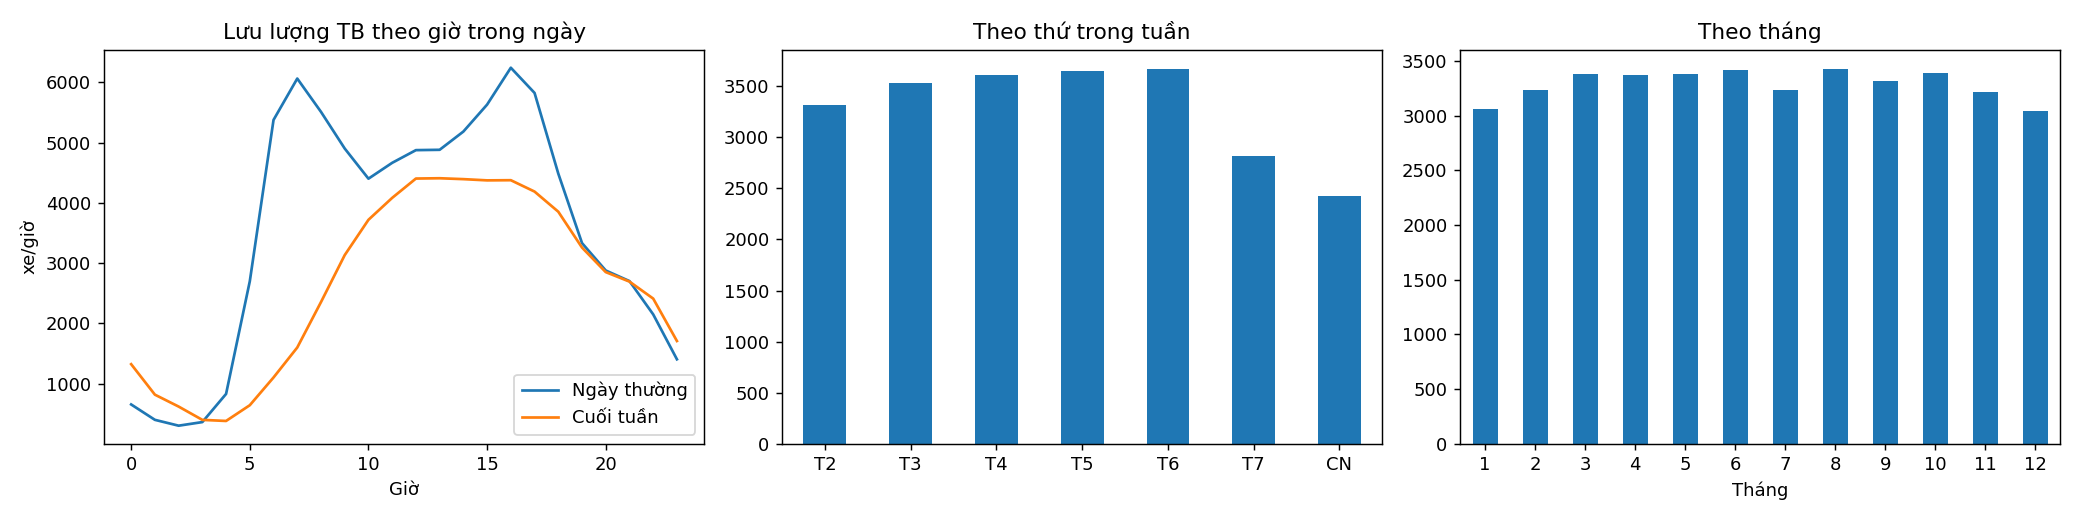

In [3]:
ve_eda(ctx)
img("eda_theo_gio.png")

## Bước 4–5. Đặc trưng và chia theo thời gian (70 / 15 / 15)
Đặc trưng: sin/cos giờ và thứ, cờ ngày lễ, one-hot `weather_main`, ... Scaler **chỉ fit trên train**.
Cửa sổ tạo riêng trong từng đoạn liên tục, thuộc tập nào theo thời điểm đích.

In [4]:
print("Mốc bắt đầu val :", ctx.cuts[0])
print("Mốc bắt đầu test:", ctx.cuts[1])
print("Số đặc trưng    :", ctx.scaled.shape[1])
data = samples(ctx, 24, 1)
for name, (X, y, t) in data.items():
    print(f"{name:5s} X={X.shape}  từ {t.min():%Y-%m-%d} đến {t.max():%Y-%m-%d}")

Mốc bắt đầu val : 2017-04-06 11:00:00
Mốc bắt đầu test: 2018-01-02 20:00:00
Số đặc trưng    : 22
train X=(28693, 24, 22)  từ 2012-10-03 đến 2017-04-06
val   X=(6454, 24, 22)  từ 2017-04-06 đến 2018-01-02
test  X=(6478, 24, 22)  từ 2018-01-02 đến 2018-09-30


## Bước 6–8. Baseline bắt buộc + XGBoost + SimpleRNN / LSTM / GRU (dự báo 1 giờ tới)
- Naive: "giờ này = giờ này hôm qua" · Seasonal naive: "giờ này = giờ này tuần trước" (baseline mạnh — LSTM phải thắng nó).
- XGBoost + lag features (TT-31).
- Tất cả được chấm trên **cùng một tập giờ test**.

[XGBoost + lag] đang huấn luyện ...
[SimpleRNN] đang huấn luyện ...
    38 epoch, 107s
[LSTM] đang huấn luyện ...
    40 epoch, 360s
[GRU] đang huấn luyện ...
    38 epoch, 327s


Mô hình,MAE,RMSE,Thời gian train (s),Số tham số,Số epoch/cây
Naive (hôm qua),560.3,1022.9,0.0,-,0
Seasonal naive (tuần trước),336.8,646.2,0.0,-,0
XGBoost + lag,144.0,223.0,1.9,-,371
SimpleRNN,170.3,255.5,107.0,"8,705",38
LSTM,167.2,251.4,359.8,"34,721",40
GRU,164.0,243.3,327.0,"26,337",38


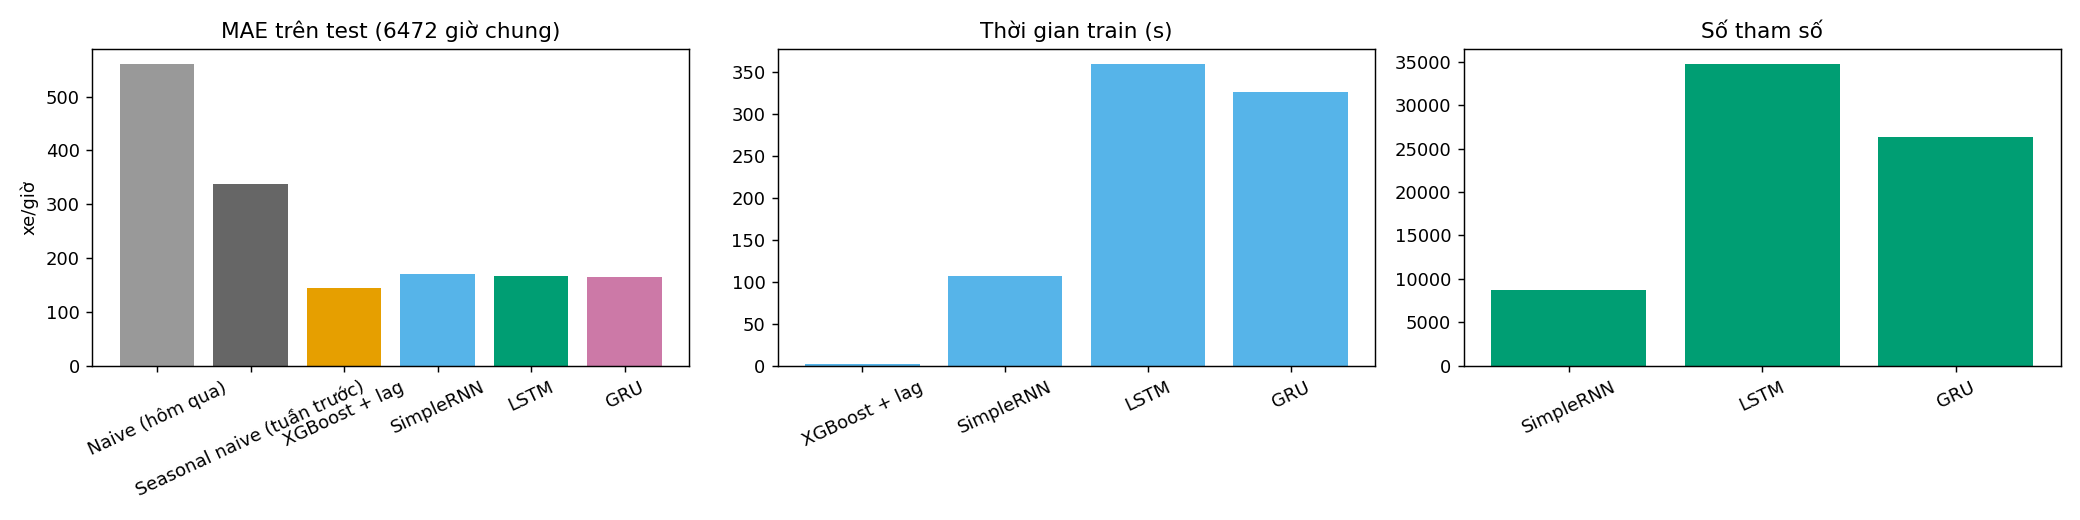

In [5]:
cmp = run_compare(ctx)
display(cmp["table"].style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "Thời gian train (s)": "{:.1f}"}).hide(axis="index"))
img("rnn_lstm_gru.png")

## Bước 9. Khảo sát độ dài cửa sổ (6 / 12 / 24 / 48 giờ)

[LSTM] cửa sổ 6h ...
[LSTM] cửa sổ 12h ...
[LSTM] cửa sổ 48h ...


Cửa sổ (giờ),MAE,RMSE,Thời gian train (s)
6,154.4,231.6,118.4
12,156.7,230.4,186.8
24,167.2,250.9,359.8
48,162.4,241.2,642.1


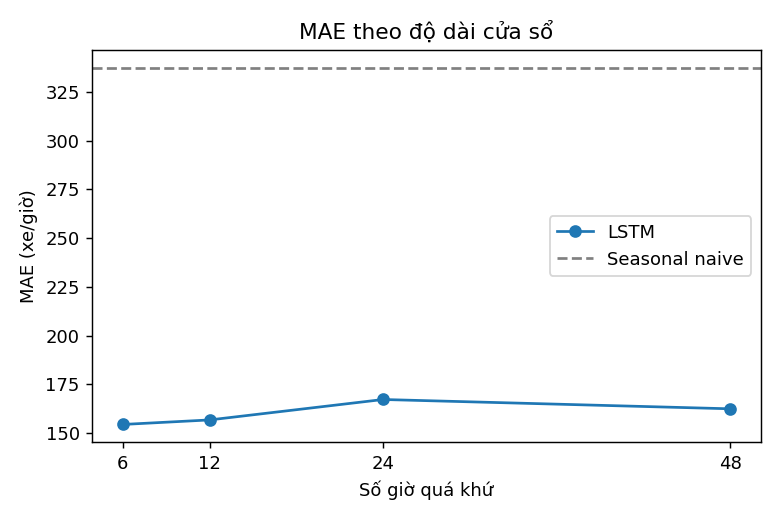

In [6]:
sweep = run_window_sweep(ctx, cmp)
display(sweep["table"].style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "Thời gian train (s)": "{:.1f}"}).hide(axis="index"))
img("do_dai_cua_so.png")

## Bước 10. Dự báo vs thực tế trên 1 tuần cuối của tập test

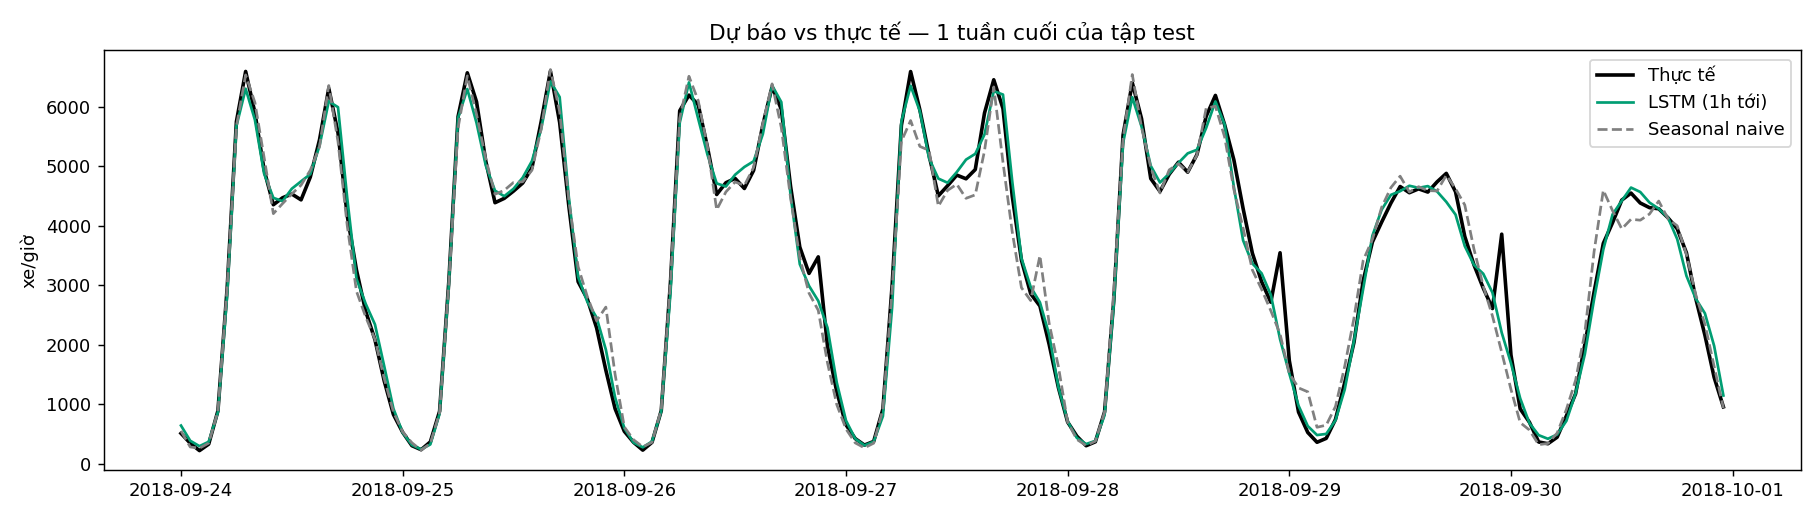

In [7]:
ve_tuan_cuoi(ctx, cmp)
img("du_bao_vs_thuc_te.png")

## Bước 11. Dự báo nhiều bước: 1h / 3h / 6h tới

[h=3] LSTM + XGBoost ...
[h=6] LSTM + XGBoost ...


Dự báo trước (giờ),LSTM,XGBoost + lag,Seasonal naive (tuần trước),Naive (hôm qua),LSTM tăng so với 1h (%)
1.0,167.3,144.0,337.0,559.6,0.0
3.0,221.5,185.2,337.0,559.6,32.4
6.0,229.3,205.5,337.0,559.6,37.1


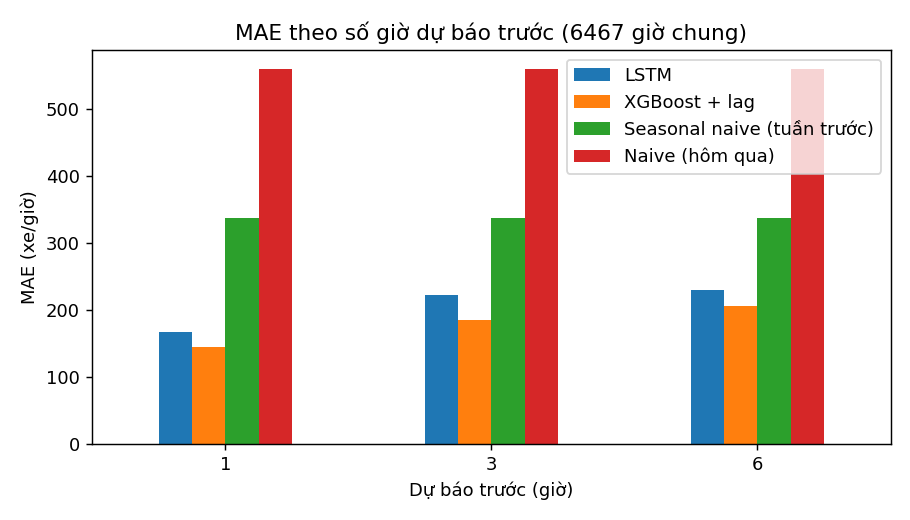

In [8]:
hor = run_horizons(ctx, cmp)
display(hor["table"].style.format("{:.1f}").hide(axis="index"))
img("du_bao_nhieu_buoc.png")

## Bước 12. Phân tích lỗi — sai nhiều nhất vào giờ nào, ngày nào?

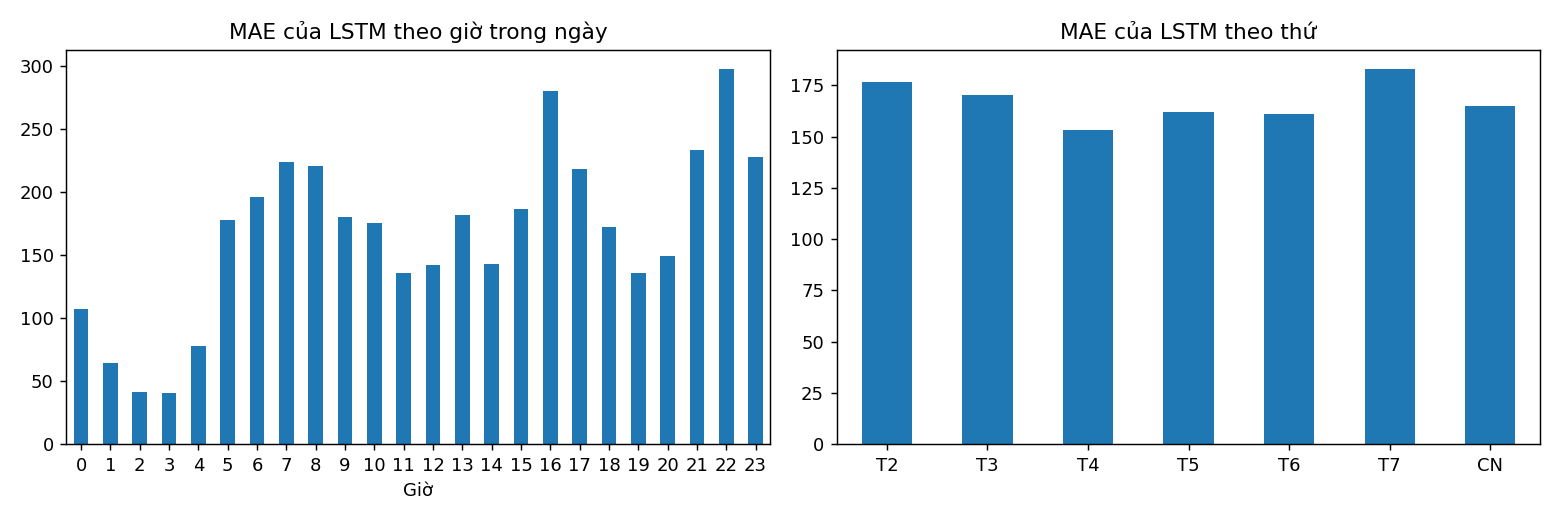

Giờ sai nhiều nhất:
 date_time
22    298.0
16    280.0
21    234.0

Ngày sai nhiều nhất:
 date_time
2018-04-14    585.0
2018-03-05    479.0
2018-01-22    467.0
2018-05-21    329.0
2018-04-15    298.0


In [9]:
err = phan_tich_loi(ctx, cmp)
img("phan_tich_loi.png")
print("Giờ sai nhiều nhất:\n", err["worst_hours"].round(0).to_string())
print("\nNgày sai nhiều nhất:\n", err["worst_days"].round(0).to_string())

## Lưu mô hình & kết luận

In [10]:
save_outputs(ctx, cmp, sweep, hor, err)   # models/lstm_traffic.keras, scaler.joblib, reports/ket_qua.md, README
display(Markdown("\n".join("- " + c for c in conclusions(cmp, sweep, hor))))

- LSTM **thắng** seasonal naive: MAE 167 so với 337 xe/giờ (giảm 50.3%).
- XGBoost + lag features cho MAE 144 (LSTM: 167) và train nhanh hơn ~192 lần → nên ưu tiên XGBoost khi triển khai.
- Trong 3 kiến trúc hồi quy, **GRU** có MAE thấp nhất (164); SimpleRNN 170 · LSTM 167 · GRU 164.
- Cửa sổ tốt nhất: **6 giờ** (MAE 154).
- LSTM dự báo 6h tới có MAE tăng 37% so với 1h tới.
- Mức tham chiếu của đề bài cho 1 giờ tới: MAE ~250–400 xe/giờ.

**Mở rộng:** Bidirectional LSTM *không hợp lý* khi dự báo tương lai (chiều ngược nhìn dữ liệu sau thời điểm hiện tại).
Seq2Seq 24 giờ và so sánh Transformer (TT-28) có thể làm tiếp trên cùng pipeline này.